In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams['figure.figsize']=(12,8)

In [3]:
data=pd.read_csv("cardekho_dataset.csv")

In [4]:
data.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [9]:
corr_mat=data.corr(numeric_only=True)
corr_mat

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
Unnamed: 0,1.000000,-0.006250,-0.003778,-0.014699,0.012972,0.039367,-0.031832,0.030523
vehicle_age,-0.006250,1.000000,0.333891,-0.257394,0.098965,0.005208,0.030791,-0.241851
km_driven,-0.003778,0.333891,1.000000,-0.105239,0.192885,0.044421,0.192830,-0.080030
mileage,-0.014699,-0.257394,-0.105239,1.000000,-0.632987,-0.533128,-0.440280,-0.305549
engine,0.012972,0.098965,0.192885,-0.632987,1.000000,0.807368,0.551236,0.585844
max_power,0.039367,0.005208,0.044421,-0.533128,0.807368,1.000000,0.172257,0.750236
seats,-0.031832,0.030791,0.192830,-0.440280,0.551236,0.172257,1.000000,0.115033
selling_price,0.030523,-0.241851,-0.080030,-0.305549,0.585844,0.750236,0.115033,1.000000


In [7]:
data.shape

(15411, 14)

In [8]:
data.info

<bound method DataFrame.info of        Unnamed: 0         car_name     brand     model  vehicle_age  \
0               0      Maruti Alto    Maruti      Alto            9   
1               1    Hyundai Grand   Hyundai     Grand            5   
2               2      Hyundai i20   Hyundai       i20           11   
3               3      Maruti Alto    Maruti      Alto            9   
4               4    Ford Ecosport      Ford  Ecosport            6   
...           ...              ...       ...       ...          ...   
15406       19537      Hyundai i10   Hyundai       i10            9   
15407       19540    Maruti Ertiga    Maruti    Ertiga            2   
15408       19541      Skoda Rapid     Skoda     Rapid            6   
15409       19542  Mahindra XUV500  Mahindra    XUV500            5   
15410       19543       Honda City     Honda      City            2   

       km_driven seller_type fuel_type transmission_type  mileage  engine  \
0         120000  Individual    Petrol

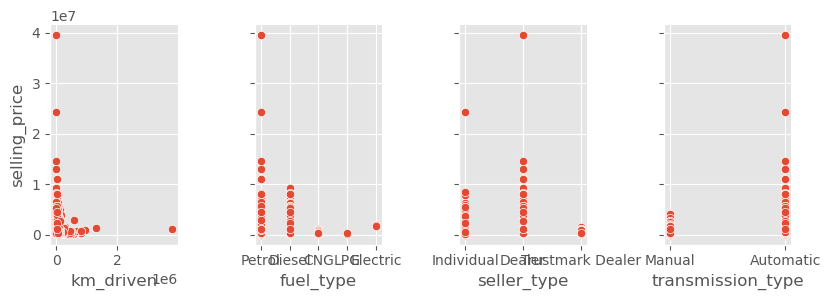

In [15]:
sns.pairplot(data,
             x_vars=['km_driven','fuel_type','seller_type','transmission_type'],
             y_vars='selling_price',
             height=3,
             aspect=0.7)

plt.show()

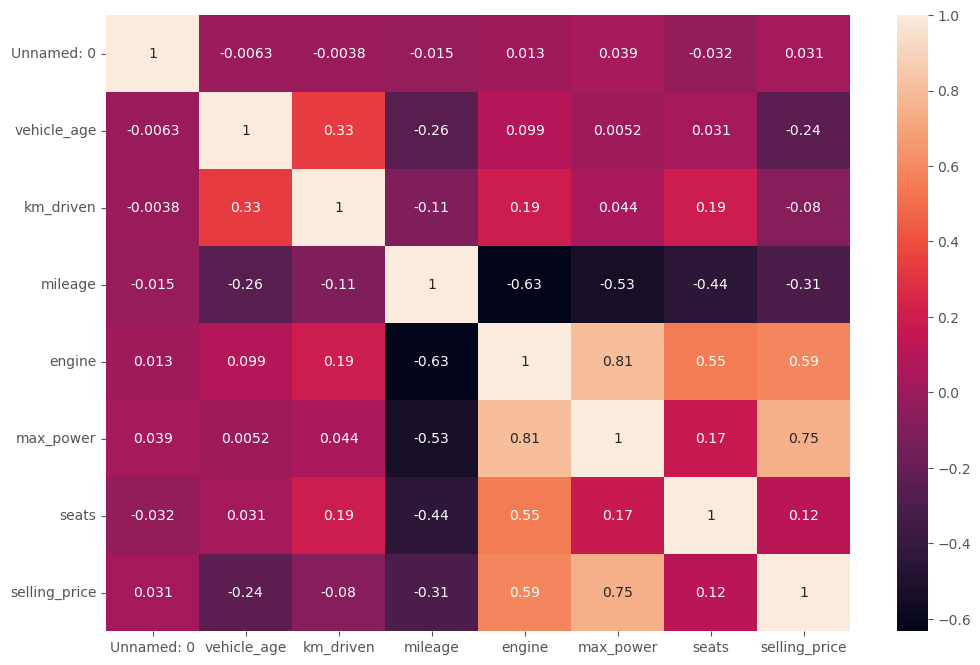

In [18]:
sns.heatmap(corr_mat,annot=True)
plt.show()

In [29]:
dropdata=data.drop(['Unnamed: 0','car_name','brand','model','seller_type','fuel_type','transmission_type'],axis='columns')
dropdata.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
0,9,120000,19.70,796,46.30,5,120000
1,5,20000,18.90,1197,82.00,5,550000
2,11,60000,17.00,1197,80.00,5,215000
3,9,37000,20.92,998,67.10,5,226000
4,6,30000,22.77,1498,98.59,5,570000


In [30]:
from sklearn.linear_model import LinearRegression

In [44]:
x=data[['mileage']]
y=data.selling_price
model=LinearRegression()
model.fit(x,y)
print("Intercept:",model.intercept_)
print("Coefficient:",model.coef_)

Intercept: 2065311.7907765768
Coefficient: [-65495.6995216]


In [46]:
new_data = pd.DataFrame({'mileage': [20]})
pred = model.predict(new_data)

print("Mileage: 10")
print("Predicted Price:", pred[0])

Mileage: 10
Predicted Price: 755397.8003446443
